# Test Main

Load a trained run and evaluate train/val splits with the Tester.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "training").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score
import torch
from testing.analyze import Analysis
from data import ESMCSingleDS
from models import SequenceActiveSiteHead
from training.losses import BinaryFocalLoss
from testing.model_test import Tester


/Users/connorott/PycharmProjects/bioml/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
data_name = "IEDB_Jespersen"
model_name = "esmc_300m"
base_data_dir = PROJECT_ROOT / "data" / "data_files"
run_dir = PROJECT_ROOT / "experiments" / "codex_test1"
trial_name = 'trial_0000'

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
)


In [4]:
dataset = ESMCSingleDS(data_name, model_name, save_dir=base_data_dir)
criterion = BinaryFocalLoss(reduction="none")

tester = Tester(
    SequenceActiveSiteHead,
    dataset,
    run_dir,
    criterion,
    trial_name=trial_name,
    device=device,
)


Dropped 4 sequences over len 5000


(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Train Logit Separation'}, xlabel='Logits', ylabel='Density'>,
        <Axes: title={'center': 'Validation Logit Separation'}, xlabel='Logits', ylabel='Density'>],
       dtype=object))

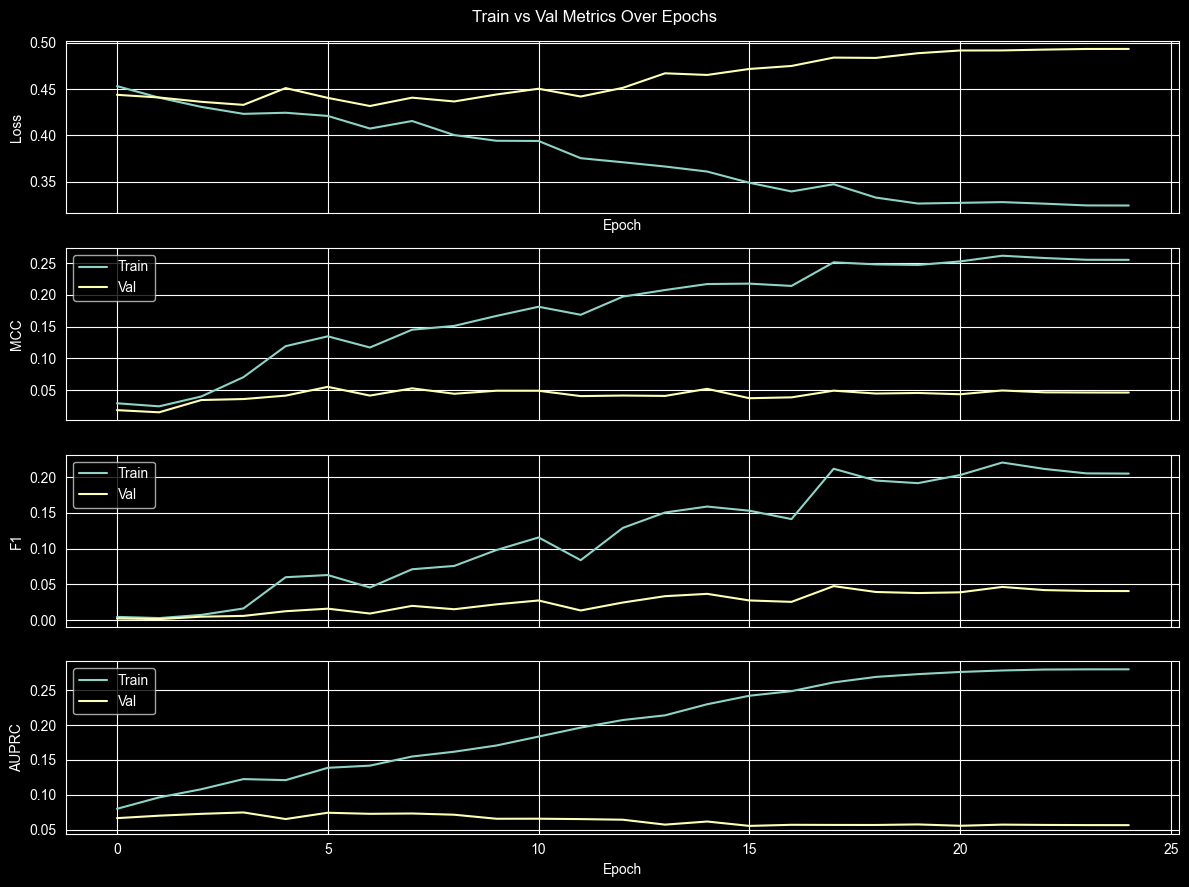

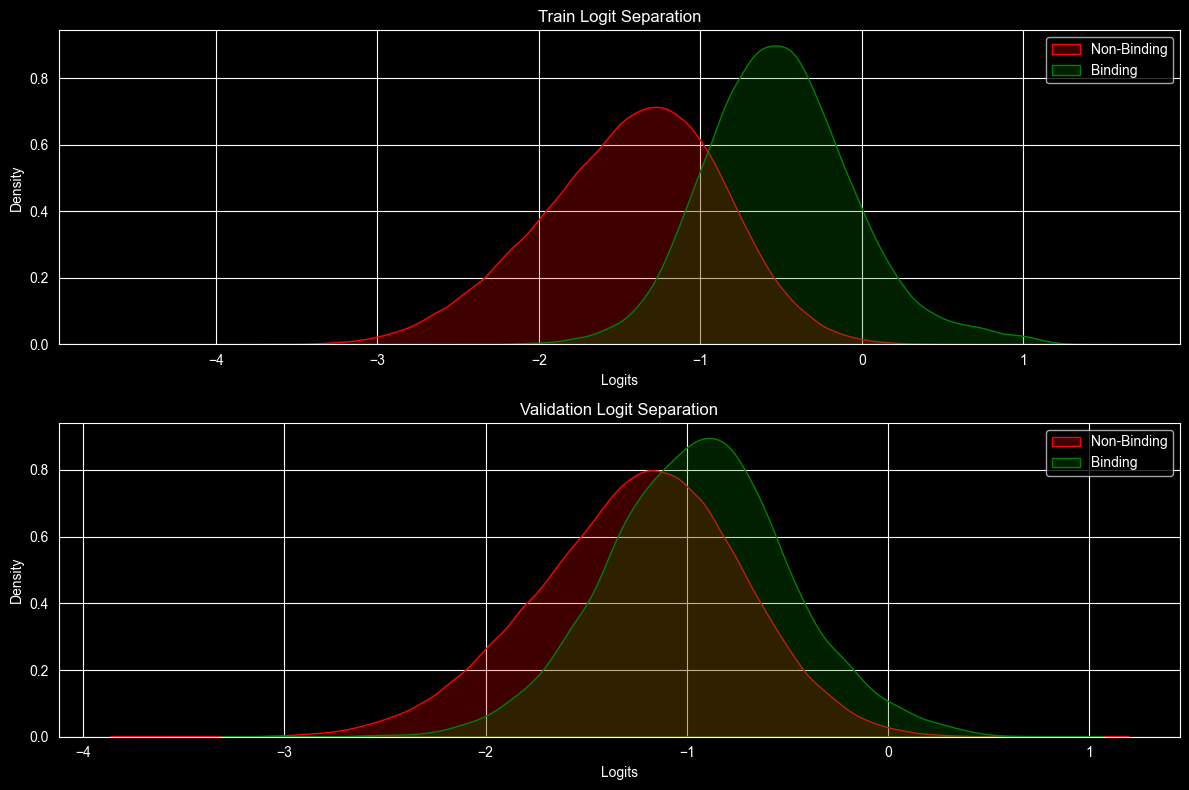

In [5]:
train_results = tester.load_evals('train')
val_results = tester.load_evals('val')
analyze = Analysis(train_results, val_results)

analyze.plot_epoch_scores()
analyze.plot_logit_separation()

In [ ]:
train_results = tester.evaluate_split("train")
val_results = tester.evaluate_split("val")

print("Train metrics:", train_results["metrics"])
print("Val metrics:", val_results["metrics"])


In [ ]:
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))


def plot_logit_separation(results, title):
    logits = results["logits"]
    labels = results["labels"]
    probs = sigmoid(logits)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.hist(probs[labels == 0], bins=100, alpha=0.6, label="Non-Binding")
    ax.hist(probs[labels == 1], bins=100, alpha=0.6, label="Binding")
    ax.set_title(title)
    ax.set_xlabel("Probability")
    ax.legend()
    plt.show()

plot_logit_separation(val_results, "Validation Logit Separation")


In [ ]:
# Optional: save evaluation outputs for later analysis
# tester.save_split_metrics("val", run_dir / "data" / "val_eval.npz")
# tester.save_split_metrics("train", run_dir / "data" / "train_eval.npz")
